# 01 · Exploratory data analysis

**Question this project asks:** *how much does the draft actually decide a solo-queue game?*

Before modelling anything, this notebook establishes what the data is and what it can
support. Three things matter most: how much data we have, whether the sides are balanced,
and how thinly champions are spread — the last one turns out to drive every modelling
decision that follows.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config, parse, features as F, viz
viz.apply_style()
pd.set_option("display.width", 140)

## The dataset

One row per ranked-solo match, built by `src/parse.py` from raw Match-V5 JSON.
Every column is known at champion-select lock, so there is **no leakage by construction** —
nothing here depends on what happened after the game started.

In [2]:
df = F.load_matches()
print(f"matches: {len(df):,}   columns: {df.shape[1]}")
print(f"patches: {sorted(df['patch'].unique())}")
print(f"region:  {config.REGION_LABEL}  (platform {config.PLATFORM_LABEL})")

span = pd.to_datetime(df["gameCreation"], unit="ms")
print(f"played:  {span.min():%d %b %Y} to {span.max():%d %b %Y}")
print(f"\nseeded from: {df['seed_tier'].value_counts().to_dict()}")
df.head(3)

matches: 8,690   columns: 26
patches: [np.float64(16.12), np.float64(16.13)]
region:  SEA (South-East Asia)  (platform sg2 - Singapore)
played:  10 Jun 2026 to 14 Jul 2026

seeded from: {'MASTER': 5860, 'GRANDMASTER': 1918, 'CHALLENGER': 620, 'UNKNOWN': 292}


,matchId,patch,gameVersion,gameCreation,win,blue1,blue2,blue3,blue4,blue5,...,blue_ban2,blue_ban3,blue_ban4,blue_ban5,red_ban1,red_ban2,red_ban3,red_ban4,red_ban5,seed_tier
0,SG2_157945922,16.12,16.12.785.1316,1781051754993,1,39,427,157,145,142,...,101,84,800,104,55,28,126,555,107,GRANDMASTER
1,SG2_157945998,16.12,16.12.785.1316,1781052139611,0,142,5,1,21,101,...,555,799,35,112,350,90,107,254,901,MASTER
2,SG2_157946817,16.12,16.12.785.1316,1781051088921,1,122,517,777,901,350,...,107,25,141,111,950,-1,800,-1,25,GRANDMASTER


The `seed_tier` column records the rank of the player whose match history surfaced each
game. **It is an approximation**: Match-V5 has no "game tier" field, and an apex game
contains a spread of nearby ranks. It is good enough to compare broad bands, not to make
precise per-tier claims.

## Is either side favoured?

Blue side is widely believed to be advantaged. Worth checking, because if one side wins
appreciably more often, that is a free signal the model will pick up — and we would want
to know how much of its performance comes from side alone rather than champions.

In [3]:
wins = df["win"].sum()
n = len(df)
p = wins / n

# Normal-approximation 95% interval on the blue win rate.
se = np.sqrt(p * (1 - p) / n)
lo, hi = p - 1.96 * se, p + 1.96 * se
print(f"blue side won {wins:,} of {n:,} games = {p:.2%}")
print(f"95% CI: {lo:.2%} to {hi:.2%}")
print("50% inside the interval?", lo <= 0.5 <= hi)

blue side won 4,191 of 8,690 games = 48.23%
95% CI: 47.18% to 49.28%
50% inside the interval? False


## How thinly are champions spread?

This is the number that governs everything downstream. A multi-hot champion model has to
estimate an effect for *every champion on every side*. If each of those cells is backed by
only a handful of games, the estimates are mostly noise and the model has to shrink them to
near zero to avoid overfitting.

In [4]:
picks = pd.concat([df[c] for c in F.BLUE_COLS + F.RED_COLS])
counts = picks.value_counts()
labels = F.load_labels()

print(f"distinct champions seen: {counts.size}")
print(f"appearances per champion -- median {counts.median():.0f}, "
      f"min {counts.min()}, max {counts.max()}")
print(f"champions appearing < 30 times: {(counts < 30).sum()}")

top = counts.head(15).rename(index=labels["name"]).rename("games")
top.to_frame()

distinct champions seen: 173
appearances per champion -- median 424, min 56, max 1960
champions appearing < 30 times: 0


,games
Sylas,1960
Seraphine,1699
Senna,1673
Ezreal,1453
Lux,1406
Kai'Sa,1368
Caitlyn,1260
Lee Sin,1209
Yasuo,1194
Jhin,1161


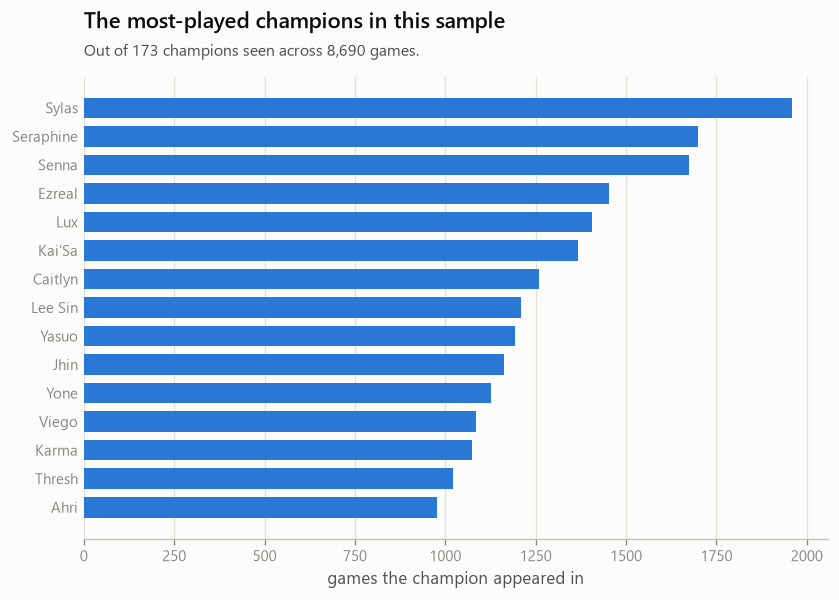

In [5]:
fig, ax = viz.figure(8, 5)
top_sorted = top.sort_values()
ax.barh(top_sorted.index, top_sorted.values, color=viz.BLUE_SIDE, height=0.72)
viz.despine_x(ax)
ax.set_xlabel("games the champion appeared in")
viz.title_block(ax, "The most-played champions in this sample",
                f"Out of {counts.size} champions seen across {len(df):,} games.")
plt.show()

## Bans

Bans are part of the draft too, so the feature matrix includes them. They behave differently
from picks: a small set of champions is banned constantly, which means those columns are
dense while most pick columns are sparse.

In [6]:
bans = pd.concat([df[c] for c in F.BAN_COLS])
bans = bans[bans != -1]
ban_counts = bans.value_counts().head(12).rename(index=labels["name"])
print(f"ban rate of the most-banned champion: {ban_counts.iloc[0] / len(df):.1%} of games")
ban_counts.rename("times banned").to_frame()

ban rate of the most-banned champion: 79.7% of games


,times banned
Locke,6923
Naafiri,3752
Mel,3750
Pyke,2830
Sylas,2463
Rengar,2053
Seraphine,1696
Nocturne,1693
Viego,1684
Yasuo,1662


## What this means for the model

1. **The label is close to balanced**, so accuracy alone would be a misleading metric — a
   constant predictor already scores near the base rate. That is why the evaluation in
   notebook 03 leads with log-loss, ROC-AUC and calibration instead.
2. **Champion data is thin and long-tailed.** With hundreds of champion-side cells and a
   limited number of games each, heavy regularisation is not optional — it is the only way
   to avoid fitting noise. Notebook 03 shows what happens when that is left to a guess.
3. **Nothing here suggests a strong draft signal.** No champion appears in enough games,
   with a large enough win-rate gap, to move a match outcome much on its own.